In [217]:
import pandas as pd
import numpy as np

In [218]:
url = "https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2023-24/gws/merged_gw.csv"
df = pd.read_csv(url)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29725 entries, 0 to 29724
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        29725 non-null  object 
 1   position                    29725 non-null  object 
 2   team                        29725 non-null  object 
 3   xP                          29725 non-null  float64
 4   assists                     29725 non-null  int64  
 5   bonus                       29725 non-null  int64  
 6   bps                         29725 non-null  int64  
 7   clean_sheets                29725 non-null  int64  
 8   creativity                  29725 non-null  float64
 9   element                     29725 non-null  int64  
 10  expected_assists            29725 non-null  float64
 11  expected_goal_involvements  29725 non-null  float64
 12  expected_goals              29725 non-null  float64
 13  expected_goals_conceded     297

In [220]:
df['assists_5avg']=df.groupby('GW')['assists'].transform(lambda x:x.shift(1).rolling(5).mean())
df['goals_conceded_5avg']=df.groupby('GW')['goals_conceded'].transform(lambda x:x.shift(1).rolling(5).mean())
df['goals_scored_5avg']=df.groupby('GW')['goals_scored'].transform(lambda x:x.shift(1).rolling(5).mean())
df['points_scored_5avg']=df.groupby('GW')['total_points'].transform(lambda x:x.shift(1).rolling(5).mean())
df['clean_sheets_5avg']=df.groupby('GW')['clean_sheets'].transform(lambda x:x.shift(1).rolling(5).mean())

In [221]:
df.drop(columns=['xP','fixture','minutes','expected_goal_involvements','selected','expected_goals','expected_assists','threat','expected_goals_conceded','influence','ict_index','assists','bonus','bps','bonus','clean_sheets','goals_conceded','goals_scored','element','kickoff_time','own_goals','creativity','transfers_balance','opponent_team','penalties_saved','penalties_missed','red_cards','round','saves','starts','team_a_score','team_h_score','transfers_in','transfers_out','yellow_cards'],inplace=True)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29725 entries, 0 to 29724
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 29725 non-null  object 
 1   position             29725 non-null  object 
 2   team                 29725 non-null  object 
 3   total_points         29725 non-null  int64  
 4   value                29725 non-null  int64  
 5   was_home             29725 non-null  bool   
 6   GW                   29725 non-null  int64  
 7   assists_5avg         29535 non-null  float64
 8   goals_conceded_5avg  29535 non-null  float64
 9   goals_scored_5avg    29535 non-null  float64
 10  points_scored_5avg   29535 non-null  float64
 11  clean_sheets_5avg    29535 non-null  float64
dtypes: bool(1), float64(5), int64(3), object(3)
memory usage: 2.5+ MB


In [223]:
df.sort_values(['name','GW'],inplace=True)

In [224]:
cutoff=30
train=df[df['GW']<=cutoff]
test=df[df['GW']>cutoff]

In [225]:
print(train.shape)
test.shape

(22269, 12)


(7456, 12)

In [226]:
xTrain=train.drop(columns=['total_points','name','team'])
yTrain=train['total_points']

xTest=test.drop(columns=['total_points','name','team'])
yTest=test['total_points']

In [227]:
print(yTrain.shape)
yTest.shape

(22269,)


(7456,)

In [228]:
xTrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   position             22269 non-null  object 
 1   value                22269 non-null  int64  
 2   was_home             22269 non-null  bool   
 3   GW                   22269 non-null  int64  
 4   assists_5avg         22119 non-null  float64
 5   goals_conceded_5avg  22119 non-null  float64
 6   goals_scored_5avg    22119 non-null  float64
 7   points_scored_5avg   22119 non-null  float64
 8   clean_sheets_5avg    22119 non-null  float64
dtypes: bool(1), float64(5), int64(2), object(1)
memory usage: 1.6+ MB


In [229]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',sparse_output=False)

pos_new_train=ohe.fit_transform(xTrain[['position']])
pos_new_test=ohe.transform(xTest[['position']])

xTrain=pd.concat([xTrain.drop('position',axis=1),pd.DataFrame(pos_new_train,columns=ohe.get_feature_names_out(['position']))],axis=1)
xTest = xTest.reset_index(drop=True)
xTest=pd.concat([xTest.drop('position',axis=1),pd.DataFrame(pos_new_test,columns=ohe.get_feature_names_out(['position']))],axis=1)

In [230]:
print(xTrain.shape)
xTest.shape

(22269, 11)


(7456, 11)

In [231]:
import xgboost as xgb
xg=xgb.XGBRegressor(max_depth=5,learning_rate=0.05,random_state=42,n_estimators=200)
xg.fit(xTrain,yTrain)
yPred=xg.predict(xTest)

In [232]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

print("Mean Absolute Error: ",mean_absolute_error(yTest,yPred))
print("Mean Squared Error: ",mean_squared_error(yTest,yPred))
print("r2 score: ",r2_score(yTest,yPred))

Mean Absolute Error:  1.1984556913375854
Mean Squared Error:  4.65080451965332
r2 score:  0.11168015003204346


In [249]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'n_estimators':[200,250,300,350],
    'learning_rate':[0.01,0.02,0.04],
    'max_depth':[4,5,6]
}

grid=GridSearchCV(xg,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)
grid.fit(xTrain,yTrain)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=5, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=200,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.02, 0.04],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [200, 250, 300, 350]},
             scoring='r2')

In [250]:
best_model=grid.best_estimator_
print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}


In [251]:
bestPred=best_model.predict(xTest)
print("Mean Absolute Error: ",mean_absolute_error(yTest,bestPred))
print("Mean Squared Error: ",mean_squared_error(yTest,bestPred))
print("r2 score: ",r2_score(yTest,bestPred))

Mean Absolute Error:  1.2308719158172607
Mean Squared Error:  4.612300395965576
r2 score:  0.1190345287322998


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

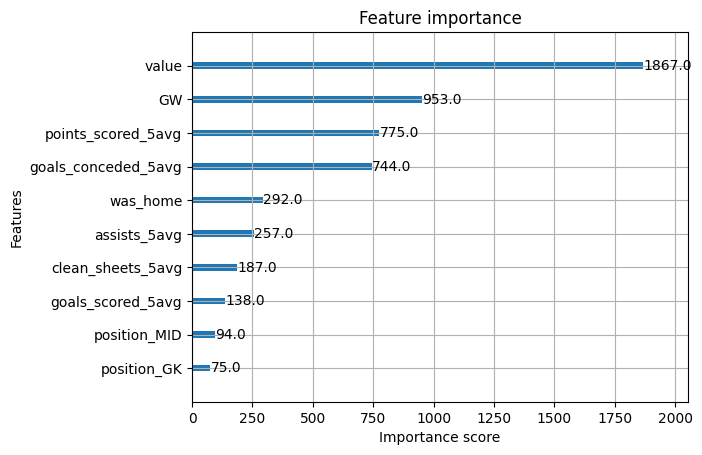

In [233]:
xgb.plot_importance(xg,max_num_features=10)

In [234]:
pd.Series(xg.feature_importances_,index=list(xTrain.columns)).sort_values(ascending=False)

,0
value,0.294014
clean_sheets_5avg,0.101948
position_FWD,0.084559
points_scored_5avg,0.073679
goals_scored_5avg,0.072139
GW,0.070687
position_GK,0.070684
goals_conceded_5avg,0.070500
assists_5avg,0.067858
position_MID,0.047599


In [236]:
baseline_pred=yTrain.mean()
baseline_mae=mean_absolute_error(train['total_points'],[baseline_pred]*len(train))
print("Baseline MAE:", baseline_mae)
print("Model MAE:   ", mean_absolute_error(yTest,yPred))

Baseline MAE: 1.4090625828347343
Model MAE:    1.1984556913375854


In [237]:
yTrain_shuffled = yTrain.sample(frac=1.0, random_state=42).values
model_shuffled = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_shuffled.fit(xTrain, yTrain_shuffled)
preds_shuffled = model_shuffled.predict(xTest)

In [242]:
print("For Shuffled data")
print("Mean Absolute Error: ",mean_absolute_error(yTest,preds_shuffled))
print("Mean Squared Error: ",mean_squared_error(yTest,preds_shuffled))
print("r2 score: ",r2_score(yTest,preds_shuffled))

For Shuffled data
Mean Absolute Error:  1.4191398620605469
Mean Squared Error:  5.423050880432129
r2 score:  -0.03582155704498291


In [243]:
from scipy.stats import spearmanr

test = test.copy()
test['pred'] = yPred

results = []
for gw in sorted(test['GW'].unique()):
    gw_df = test[test['GW'] == gw]
    corr, _ = spearmanr(gw_df['pred'], gw_df['total_points'])
    actual_top5 = set(gw_df.nlargest(5, 'total_points')['name'])
    pred_top5   = set(gw_df.nlargest(5, 'pred')['name'])
    overlap     = len(actual_top5 & pred_top5) / 5
    results.append({'GW': gw, 'spearman': corr, 'prec@5': overlap})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("Mean Spearman:", results_df['spearman'].mean())
print("Mean Prec@5  :", results_df['prec@5'].mean())

 GW  spearman  prec@5
 31  0.399281     0.2
 32  0.434060     0.0
 33  0.381031     0.0
 34  0.397091     0.0
 35  0.393051     0.0
 36  0.427766     0.0
 37  0.413737     0.0
 38  0.400234     0.0
Mean Spearman: 0.4057811270032321
Mean Prec@5  : 0.025


In [252]:
print("Features:", list(xTrain.columns))

Features: ['value', 'was_home', 'GW', 'assists_5avg', 'goals_conceded_5avg', 'goals_scored_5avg', 'points_scored_5avg', 'clean_sheets_5avg', 'position_FWD', 'position_GK', 'position_MID']


In [253]:
import joblib
joblib.dump(xg,'model.pkl')
joblib.dump(ohe,'transform.pkl')
joblib.dump(list(xTrain.columns),'features.pkl')

['features.pkl']

In [261]:
xTrain.columns

Index(['value', 'was_home', 'GW', 'assists_5avg', 'goals_conceded_5avg',
       'goals_scored_5avg', 'points_scored_5avg', 'clean_sheets_5avg',
       'position_FWD', 'position_GK', 'position_MID'],
      dtype='object')

In [255]:
features=['name','value','was_home', 'GW', 'assists_5avg', 'goals_conceded_5avg', 'goals_scored_5avg', 'points_scored_5avg', 'clean_sheets_5avg', 'position']
serving_df=df[features]
serving_df.to_parquet('data.parquet',index=False)

print("Serving shape:", serving_df.shape)
print("GW range:", serving_df['GW'].min(), "-", serving_df['GW'].max())

Serving shape: (29725, 10)
GW range: 1 - 38


In [272]:
model=joblib.load('model.pkl')
data=pd.read_parquet('data.parquet')
features=joblib.load('features.pkl')
encoder=joblib.load('transform.pkl')

In [278]:
budget=80
position='MID'
GW=22

candidates=data[(data['value']<=budget) & (data['position']==position) & (data['GW']==GW)]

encoded_position=encoder.transform(candidates[['position']])

X=pd.concat([
    candidates.drop(columns=['position', 'name']),
    pd.DataFrame(
        encoded_position,
        columns=encoder.get_feature_names_out(['position']),
        index=candidates.index
    )
], axis=1)

candidates['pred']=model.predict(X)

/tmp/ipykernel_1798/2007764585.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates['pred']=model.predict(X)


In [280]:
top5=candidates.nlargest(5,'pred')[['name','value','pred']]

In [281]:
top5

,name,value,pred
9741,Gabriel Martinelli Silva,77,4.610832
7347,Diogo Teixeira da Silva,79,4.191559
24689,Rodrigo Hernandez,56,3.661776
23582,Phil Foden,80,3.607367
7654,Dominik Szoboszlai,71,3.585350
